# **Customer Churn Forecasting using Machine Learning**

## **Importing the dependencies**

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

%matplotlib inline

In [3]:
# Configurations
pd.set_option('display.max_columns', None)

## **Data Understanding**

In [4]:
# Loading the dataset into a pandas dataframe
df = pd.read_csv('Telco-Customer-Churn.csv')

In [5]:
# Size of the data
df.shape

(7043, 21)

In [6]:
# First 5 rows of the data
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
# Basic information about the data
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [8]:
# Checking duplicate values in the data
df.duplicated().sum()

np.int64(0)

In [9]:
# Dropping customerID column
df = df.drop('customerID',axis=1)

In [10]:
# Printing the unique values in each categorical column
cat_col = df.select_dtypes(include='object').columns
for i in cat_col:
    print(i, df[i].unique())
    print('-'*50)

gender <ArrowStringArray>
['Female', 'Male']
Length: 2, dtype: str
--------------------------------------------------
Partner <ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str
--------------------------------------------------
Dependents <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str
--------------------------------------------------
PhoneService <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str
--------------------------------------------------
MultipleLines <ArrowStringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str
--------------------------------------------------
InternetService <ArrowStringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str
--------------------------------------------------
OnlineSecurity <ArrowStringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
--------------------------------------------------
OnlineBackup <ArrowStringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str
--------------------

/var/folders/sk/2l9d829d0cd7yjbvzmc37hzm0000gn/T/ipykernel_48322/3953303433.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_col = df.select_dtypes(include='object').columns


In [11]:
# Dealing with TotalCharges column

# Converting empty string values to 0.0
df['TotalCharges'] = df['TotalCharges'].replace(' ', '0.0')

# Changing TotalCharges datatype to float
df['TotalCharges'] = df['TotalCharges'].astype(float)

In [12]:
# Checking the class distribution of target column
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

**Class imbalance exists**

## **Exploratory Data Analysis**

In [13]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [14]:
# Inspecting SeniorCitizen column
df['SeniorCitizen'].value_counts()

SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64

In [15]:
# Converting senior citizen to a categorical column
df['SeniorCitizen'] = df['SeniorCitizen'].astype(str)

In [16]:
# Understanding the distribution of the numerical columns
def plot_histogram(col):
    plt.figure(figsize=(8,4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')

    # mean and median values for the columns
    col_mean = df[col].mean()
    col_median = df[col].median()
    plt.axvline(col_mean, color='red', linestyle='--', label='Mean')
    plt.axvline(col_median, color='green', linestyle='--', label='Median')

    plt.legend()

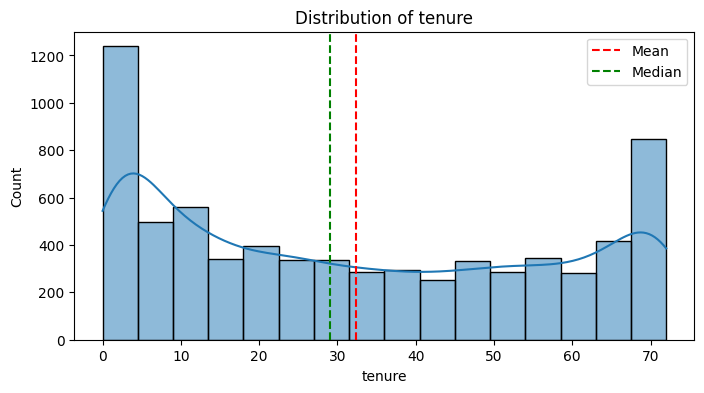

In [17]:
plot_histogram('tenure')

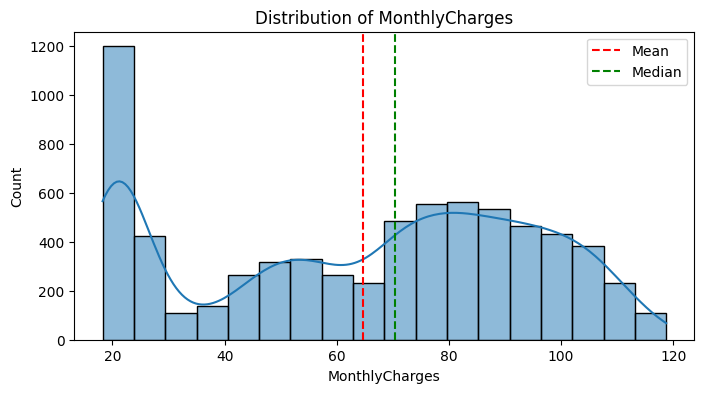

In [18]:
plot_histogram('MonthlyCharges')

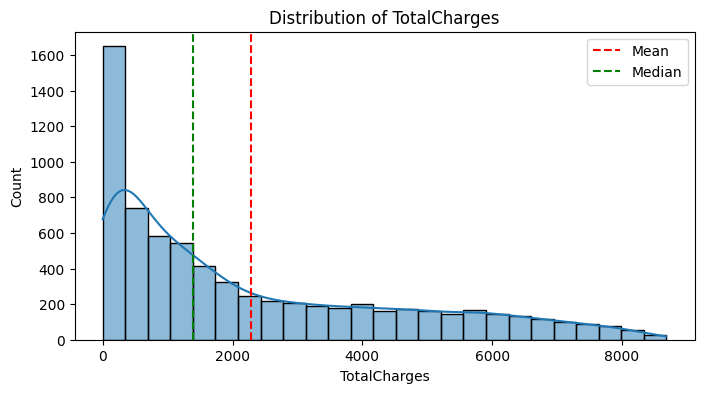

In [19]:
plot_histogram('TotalCharges')

Text(0.5, 1.0, 'Correlation heatmap')

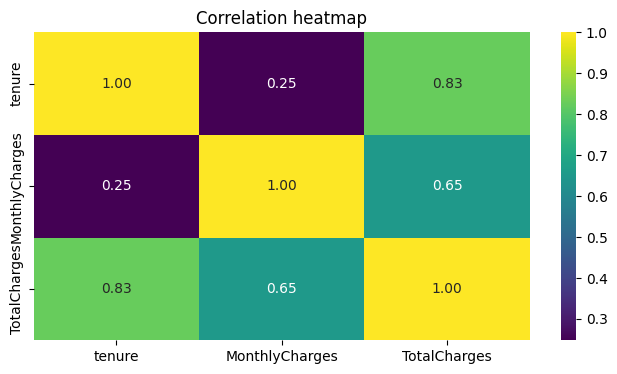

In [20]:
# Correlation of numerical features
plt.figure(figsize=(8,4))
sns.heatmap(df[['tenure','MonthlyCharges','TotalCharges']].corr(),annot=True,cmap='viridis',fmt='.2f')
plt.title('Correlation heatmap')

## **Data Preprocessing**

In [21]:
# Changing the label column
df['Churn'] = df['Churn'].map({'No':0,'Yes':1})

### Train Test Split

In [22]:
X = df.drop('Churn',axis=1)
y = df['Churn']

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

### Preprocessing Pipeline

In [24]:
# Separating the numerical and categorical features
num = X_train.select_dtypes(include='number').columns
cat = X_train.select_dtypes(include='object').columns.drop('Contract')
contract = ['Contract'] # Contract feature will require label encoding since its values are ordinal

# Creating the pipelines 
base_preprocessor = ColumnTransformer(
    [
        ('num',StandardScaler(),num),
        ('cat',OneHotEncoder(handle_unknown='ignore',drop='first'),cat),
        ('contract', OrdinalEncoder(categories=[['Month-to-month', 'One year', 'Two year']]), contract)
    ]
)

/var/folders/sk/2l9d829d0cd7yjbvzmc37hzm0000gn/T/ipykernel_48322/3859280784.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat = X_train.select_dtypes(include='object').columns.drop('Contract')


### Selecting the best model

In [25]:
models = {
    'Decision Tree': DecisionTreeClassifier(random_state=101),
    'Random Forest': RandomForestClassifier(random_state=101),
    'Hist Gradient Boost': HistGradientBoostingClassifier(random_state=101)
}

In [26]:
# Cross validation
for name, model in models.items():
    pipeline = Pipeline(
        steps=[
        ('basepreprocess', base_preprocessor),
        ('smote',SMOTE(random_state=101)),
        ('model', model)
    ])
    
    scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='f1')
    print(f'{name}: Mean F1 = {scores.mean():.4f}')

Decision Tree: Mean F1 = 0.5068
Random Forest: Mean F1 = 0.5859
Hist Gradient Boost: Mean F1 = 0.5932


**Best model: Hist Gradient Boost**

### Hyperparameter tuning

In [27]:
param_grid = {
    'model__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'model__max_iter': [100, 200, 300],
    'model__max_depth': [None, 5, 10],
    'model__min_samples_leaf': [20, 50],
    'model__l2_regularization': [0.0, 0.1, 1.0]
}

In [28]:
pipeline = Pipeline(
    [
        ('basepreprocess', base_preprocessor),
        ('smote',SMOTE(random_state=101)),
        ('model',HistGradientBoostingClassifier(random_state=101))
    ]
)

In [29]:
# Grid Search CV: to get the best parameter values
grid = GridSearchCV(pipeline, param_grid, cv=5, scoring='f1', n_jobs=-1, verbose=1)

In [30]:
grid.fit(X_train,y_train)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step..._state=101))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__l2_regularization': [0.0, 0.1, ...], 'model__learning_rate': [0.01, 0.05, ...], 'model__max_depth': [None, 5, ...], 'model__max_iter': [100, 200, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the co

In [31]:
# Getting the best parameters
grid.best_params_

{'model__l2_regularization': 1.0,
 'model__learning_rate': 0.01,
 'model__max_depth': 5,
 'model__max_iter': 300,
 'model__min_samples_leaf': 20}

## **Model Training**

In [32]:
hist_gradient_model = Pipeline(
    [
        ('basepreprocess', base_preprocessor),
        ('smote',SMOTE(random_state=101)),
        ('model',HistGradientBoostingClassifier(random_state=101,l2_regularization=1.0,learning_rate=0.01,max_depth=5,max_iter=300,min_samples_leaf=20))
    ]
)

In [33]:
hist_gradient_model.fit(X_train,y_train)

,steps,"[('basepreprocess', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatti

## **Model Evaluation**

In [34]:
# Evaluating on testing data
predictions = hist_gradient_model.predict(X_test)

In [35]:
# Classification report and confusion matrix to evaluate the model
print('Confusion matrix:','\n',confusion_matrix(y_test,predictions),'\n')
print('Classification report:','\n',classification_report(y_test,predictions))

Confusion matrix: 
 [[1235  311]
 [ 155  412]] 

Classification report: 
               precision    recall  f1-score   support

           0       0.89      0.80      0.84      1546
           1       0.57      0.73      0.64       567

    accuracy                           0.78      2113
   macro avg       0.73      0.76      0.74      2113
weighted avg       0.80      0.78      0.79      2113



## **Building a predictive system**

In [36]:
import random
num = random.randint(0,len(X_test)-1)

In [37]:
X_new = X_test.reset_index(drop=True).iloc[[num]]
pred = hist_gradient_model.predict(X_new)

print('Forecasted:',end=' ')
if pred[0] == 1:
    print('Customer will churn (Cancel their plan)')
else:
    print('Customer will not churn (Continue their plan)')

# Actual value
y = y_test.reset_index(drop=True)
print('Actuality:', end=' ')
if y[num] == 1:
    print('Customer will churn (Cancel their plan)')
else:
    print('Customer will not churn (Continue their plan)')

Forecasted: Customer will not churn (Continue their plan)
Actuality: Customer will not churn (Continue their plan)


## **Saving the model**

In [41]:
import pickle

with open('model.pkl', 'wb') as f:
    pickle.dump(hist_gradient_model, f)